## 0. Setup

In [1]:
# set libraries to refresh
%load_ext autoreload
%autoreload 2

In [2]:
# general
from pathlib import Path

import geopandas as gpd

# for plotting and coloring
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import ListedColormap
from tqdm.notebook import tqdm

gpd.options.io_engine = "pyogrio"

In [3]:
from gridsample.utils import create_gmap_links, save_shapefiles
# from gridsample.mapping import create_interactive_map

In [4]:
from utils import (
    download_VIDA_rooftops_data_by_s2,
    generate_colormap,
    get_matched_rooftop_centroids_from_s2_file,
    get_s2_cell_ids,
    s2_cell_ids_to_shapes_gdf,
)

In [5]:
ROOT_DIR = Path("../")
DATA_DIR = ROOT_DIR / "data_panel"
RAW_DATA_DIR = DATA_DIR / "01. Raw Data" #symlinked from IFS folder
CLEANED_DATA_DIR = DATA_DIR / "02. Intermediate Outputs" / "replacements_v2_mumbai_main"
OUTPUT_DATA_DIR = DATA_DIR / "03. Final Outputs" / "replacements_v2_mumbai_main"
OUTPUT_DATA_DIR.mkdir(parents=True, exist_ok=True)

## 1. Load MapSolve boundaries

In [6]:
# get all filepaths that end in `gpkg` inside the RAW_DATA_DIR / 0.1. MapSolve Boundaries
boundaries_dir = RAW_DATA_DIR / "01. MapSolve Boundaries"
gpkg_files_all = list(boundaries_dir.glob("**/*.gpkg"))
gpkg_files_all = [f for f in gpkg_files_all if f.is_file()]
# # drop any with the word "Sub-District" in the filename
# gpkg_files_VTW = [f for f in gpkg_files_all if "Sub-District" not in f.name]
# load all shapes into one gdf
gdf_list = []
for filepath in gpkg_files_all:
    gdf_list.append(gpd.read_file(filepath))
gdf = pd.concat(gdf_list, ignore_index=True).to_crs(4326)

In [7]:
gdf = gdf.drop_duplicates()

### Fix ad-hoc issues (see quality check notebook)

In [8]:
# chittoor
gdf.loc[gdf["TV_C"] == 803014, ["SubDist_N", "SubDist_C"]] = ["Tirupati (Urban)", 5383]
# patna
gdf.loc[(gdf["TV_C"] == 801373) & (gdf["Ward_C"] == "3"), "PCA_ID"] = "801373-3"
# MDDS codes
gdf.loc[gdf["TV_C"] == 519923, ["TV_C", "Ward_C", "PCA_ID"]] = [802596, 18, "802596-18"]
gdf.loc[gdf["TV_C"] == 574077, ["TV_C", "Ward_C", "PCA_ID"]] = [802918, 157, "802918-157"]

<Axes: >

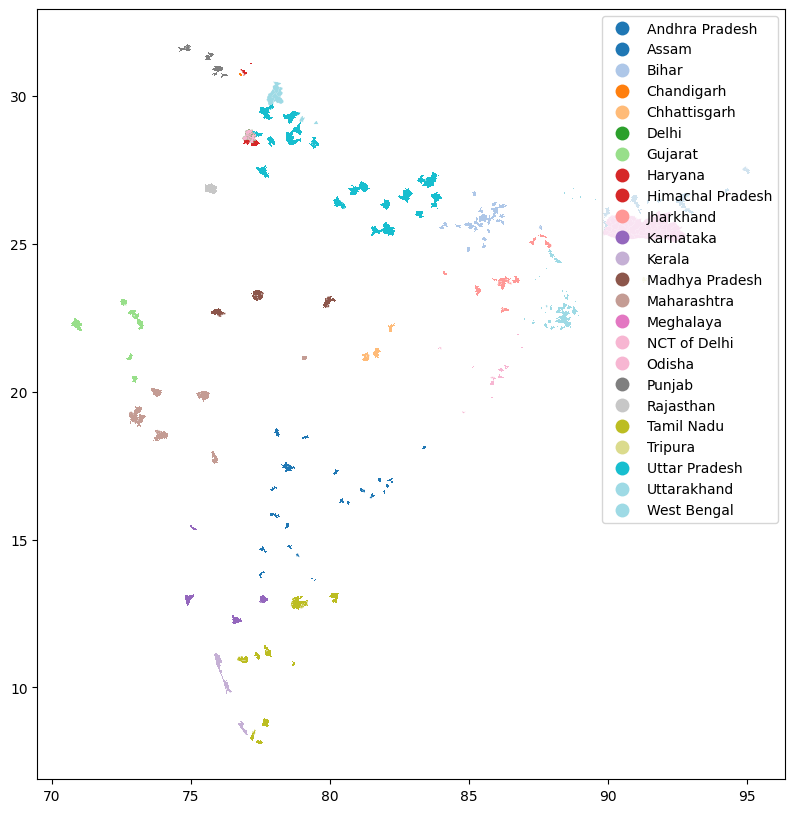

In [9]:
gdf.plot(column="State_N", legend=True, figsize=(10, 10), cmap="tab20")

## 2. Load sampled wards data

In [10]:
# load the merged wards data
sample_df = pd.read_csv(
    CLEANED_DATA_DIR
    / "00. Merge and Quality Checks"
    / "Panel Wards with Quality Checks.csv"
)

### 2.1 Rename and clean both datasets

In [11]:
rename_dict = {
    "UID": "UID",
    "PCA_ID": "PCA_ID",
    "State_C": "State Code",
    "State_N": "State Name",
    "Dist_C": "District Code",
    "Dist_N": "District Name",
    "SubDist_C": "Subdistrict Code",
    "SubDist_N": "Subdistrict Name",
    "TV_C": "TV Code",
    "TV_N": "TV Name",
    "Ward_C": "Ward Code",
    "TOT_P": "Total Population",
}

gdf = gdf.rename(columns=rename_dict)

In [12]:
rename_dict = {
    "State": "State Code",
    "State_Name": "State Name",
    "District": "District Code",
    "District_Name": "District Name",
    "Subdistrict": "Subdistrict Code",
    "Subd_Name": "Subdistrict Name",
    "TownVillage": "TV Code",
    "UrbanWardVillage": "Ward Code",
    "WardVillage_Name": "Ward/Village Name",
    "TRU": "Urban/Rural",
    "WardVillage_Pop": "Ward Population",
    "Subd_Pop": "Subdistrict Population",
    "State_Pop": "State Population",
    "WardVillageID": "Complete ID",
}
sample_df = sample_df.rename(columns=rename_dict)

# make State Name heading case instead of all caps
sample_df["State Name"] = sample_df["State Name"].str.title()
sample_df.loc[sample_df["State Name"] == "Nct Of Delhi", "State Name"] = "NCT of Delhi"

In [13]:
# make relevant codes into floats for both datasets
code_columns = [
    "State Code",
    "District Code",
    "Subdistrict Code",
    "TV Code",
    "Ward Code",
]
for col in code_columns:
    sample_df[col] = sample_df[col].astype(float)
    gdf[col] = gdf[col].astype(float)

## 3. Filter MapSolve boundaries to sampled areas

### 3.2 Drop unnecessary rows 

#### Drop rows with no MapSolve shapes

In [14]:
sample_df[sample_df["PSU Type"] == "none"]

,State Code,State Name,District Code,District Name,Subdistrict Code,Subdistrict Name,TV Code,Ward Code,Ward/Village Name,PCA_ID,...,Ward Boundary Available with MapSolve,State Shared by MapSolve,State Changed,Ward Boundary Given,TV Boundary Given,SubDistrict Boundary Given,Delivery State,PSU Type,PSU ID,Ward Count


In [15]:
filtered_df = sample_df[sample_df["PSU Type"] != "none"]

In [16]:
filtered_df

,State Code,State Name,District Code,District Name,Subdistrict Code,Subdistrict Name,TV Code,Ward Code,Ward/Village Name,PCA_ID,...,Ward Boundary Available with MapSolve,State Shared by MapSolve,State Changed,Ward Boundary Given,TV Boundary Given,SubDistrict Boundary Given,Delivery State,PSU Type,PSU ID,Ward Count
0,27.0,Maharashtra,518.0,Mumbai Suburban,99999.0,Area not under any Sub-district,802794.0,1045.0,Greater Mumbai (M Corp.) (Part) WARD NO.-1045,802794-1045,...,Yes,True,No,True,False,False,GOOD - Ward boundary given as expected,ward,WARD_802794-1045,1
1,27.0,Maharashtra,518.0,Mumbai Suburban,99999.0,Area not under any Sub-district,802794.0,1139.0,Greater Mumbai (M Corp.) (Part) WARD NO.-1139,802794-1139,...,Yes,True,No,True,False,False,GOOD - Ward boundary given as expected,ward,WARD_802794-1139,1
2,27.0,Maharashtra,518.0,Mumbai Suburban,99999.0,Area not under any Sub-district,802794.0,1140.0,Greater Mumbai (M Corp.) (Part) WARD NO.-1140,802794-1140,...,Yes,True,No,True,False,False,GOOD - Ward boundary given as expected,ward,WARD_802794-1140,1
3,27.0,Maharashtra,518.0,Mumbai Suburban,99999.0,Area not under any Sub-district,802794.0,1141.0,Greater Mumbai (M Corp.) (Part) WARD NO.-1141,802794-1141,...,Yes,True,No,True,False,False,GOOD - Ward boundary given as expected,ward,WARD_802794-1141,1
4,27.0,Maharashtra,518.0,Mumbai Suburban,99999.0,Area not under any Sub-district,802794.0,1353.0,Greater Mumbai (M Corp.) (Part) WARD NO.-1353,802794-1353,...,Yes,True,No,True,False,False,GOOD - Ward boundary given as expected,ward,WARD_802794-1353,1
5,27.0,Maharashtra,518.0,Mumbai Suburban,99999.0,Area not under any Sub-district,802794.0,1565.0,Greater Mumbai (M Corp.) (Part) WARD NO.-1565,802794-1565,...,Yes,True,No,True,False,False,GOOD - Ward boundary given as expected,ward,WARD_802794-1565,1
6,27.0,Maharashtra,518.0,Mumbai Suburban,99999.0,Area not under any Sub-district,802794.0,1566.0,Greater Mumbai (M Corp.) (Part) WARD NO.-1566,802794-1566,...,Yes,True,No,True,False,False,GOOD - Ward boundary given as expected,ward,WARD_802794-1566,1
7,27.0,Maharashtra,518.0,Mumbai Suburban,99999.0,Area not under any Sub-district,802794.0,1667.0,Greater Mumbai (M Corp.) (Part) WARD NO.-1667,802794-1667,...,Yes,True,No,True,False,False,GOOD - Ward boundary given as expected,ward,WARD_802794-1667,1
8,27.0,Maharashtra,518.0,Mumbai Suburban,99999.0,Area not under any Sub-district,802794.0,1770.0,Greater Mumbai (M Corp.) (Part) WARD NO.-1770,802794-1770,...,Yes,True,No,True,False,False,GOOD - Ward boundary given as expected,ward,WARD_802794-1770,1
9,27.0,Maharashtra,518.0,Mumbai Suburban,99999.0,Area not under any Sub-district,802794.0,1975.0,Greater Mumbai (M Corp.) (Part) WARD NO.-1975,802794-1975,...,Yes,True,No,True,False,False,GOOD - Ward boundary given as expected,ward,WARD_802794-1975,1


In [17]:
# check bad rows, leave as is though
filtered_df[filtered_df["Delivery State"].str.contains("BAD")]

,State Code,State Name,District Code,District Name,Subdistrict Code,Subdistrict Name,TV Code,Ward Code,Ward/Village Name,PCA_ID,...,Ward Boundary Available with MapSolve,State Shared by MapSolve,State Changed,Ward Boundary Given,TV Boundary Given,SubDistrict Boundary Given,Delivery State,PSU Type,PSU ID,Ward Count


#### Duplicated wards

In [18]:
filtered_df[filtered_df["PCA_ID"].duplicated(keep=False)]

,State Code,State Name,District Code,District Name,Subdistrict Code,Subdistrict Name,TV Code,Ward Code,Ward/Village Name,PCA_ID,...,Ward Boundary Available with MapSolve,State Shared by MapSolve,State Changed,Ward Boundary Given,TV Boundary Given,SubDistrict Boundary Given,Delivery State,PSU Type,PSU ID,Ward Count


In [19]:
print(f"Number of rows before dropping PCA_ID duplicates: {len(filtered_df)}")
print(
    f"Number of rows after dropping PCA_ID duplicates: {len(filtered_df.drop_duplicates(subset=['PCA_ID'], keep='first'))}"
)

Number of rows before dropping PCA_ID duplicates: 13
Number of rows after dropping PCA_ID duplicates: 13


In [20]:
filtered_df = filtered_df.drop_duplicates(subset=["PCA_ID"], keep="first")

#### Check for duplicated `PSU ID`

In [21]:
filtered_df[filtered_df.duplicated(subset=["PSU ID"], keep=False)]

,State Code,State Name,District Code,District Name,Subdistrict Code,Subdistrict Name,TV Code,Ward Code,Ward/Village Name,PCA_ID,...,Ward Boundary Available with MapSolve,State Shared by MapSolve,State Changed,Ward Boundary Given,TV Boundary Given,SubDistrict Boundary Given,Delivery State,PSU Type,PSU ID,Ward Count


In [22]:
filtered_df = filtered_df.drop_duplicates(subset=["PSU ID"], keep="first")
len(filtered_df) == filtered_df["PSU ID"].nunique()

True

## 4. Merge shapes at the respective PSU level

### Wards

In [23]:
# PCA IDs to match (TVCode-WardCode)
pca_ids_to_match = filtered_df.loc[filtered_df["PSU Type"] == "ward", "PCA_ID"].unique()
len(pca_ids_to_match)

13

In [24]:
wards_gdf = gpd.GeoDataFrame(
    filtered_df[filtered_df["PSU Type"] == "ward"].merge(
        gdf[gdf["PCA_ID"].isin(pca_ids_to_match)],
        on=["PCA_ID"],
        how="left",
        suffixes=("", "_MapSolve"),
    ),
    geometry="geometry",
)
wards_gdf.shape

(13, 37)

### Town/Village

In [25]:
# # TV codes to match
# tv_codes_to_match = filtered_df.loc[
#     filtered_df["PSU Type"] == "town_village", "TV Code"
# ].unique()
# len(tv_codes_to_match)

In [26]:
# tv_gdf = gpd.GeoDataFrame(
#     filtered_df[filtered_df["PSU Type"] == "town_village"].merge(
#         gdf[gdf["TV Code"].isin(tv_codes_to_match) & gdf["Ward Code"].isna()],
#         on=["TV Code"],
#         how="left",
#         suffixes=("", "_MapSolve"),
#     )
# )
# tv_gdf.shape

In [27]:
# # cut out the ward geometries from the TV geometries so we don't double sample those areas
# trimmed_tv_geoms = tv_gdf.difference(wards_gdf.geometry.unary_union)
# trimmed_tv_gdf = gpd.GeoDataFrame(
#     tv_gdf.drop(columns="geometry").assign(geometry=trimmed_tv_geoms),
#     crs=tv_gdf.crs,
# )

### Subdistrict

In [28]:
# # subdistrict codes to match
# subdistrict_codes_to_match = filtered_df.loc[
#     filtered_df["PSU Type"] == "subdistrict", "Subdistrict Code"
# ].unique()
# len(subdistrict_codes_to_match)

In [29]:
# subdistrict_gdf = gpd.GeoDataFrame(
#     filtered_df[filtered_df["PSU Type"] == "subdistrict"].merge(
#         gdf[
#             gdf["Subdistrict Code"].isin(subdistrict_codes_to_match)
#             & (gdf["TV Code"].isna())
#             & (gdf["Ward Code"].isna())
#         ],
#         on=["Subdistrict Code"],
#         how="left",
#         suffixes=("", "_MapSolve"),
#     )
# )

In [30]:
# # cut out the TV and Ward geometries from the subdistrict geometries so we don't double sample those areas
# combined_tv_and_ward_union_shape = wards_gdf.geometry.unary_union.union(
#     trimmed_tv_gdf.geometry.unary_union
# )
# trimmed_subdistrict_geoms = subdistrict_gdf.difference(combined_tv_and_ward_union_shape)
# trimmed_subdistrict_gdf = gpd.GeoDataFrame(
#     subdistrict_gdf.drop(columns="geometry").assign(geometry=trimmed_subdistrict_geoms),
#     crs=subdistrict_gdf.crs,
# )

### Combine

In [31]:
# combine all three GeoDataFrames into one
combined_gdf = gpd.GeoDataFrame(
    pd.concat(
        [
            wards_gdf,
            # trimmed_tv_gdf,
            # trimmed_subdistrict_gdf,
        ],
        ignore_index=True,
    )
)
combined_gdf = combined_gdf.sort_values(
    by=["State Code", "District Code", "Subdistrict Code", "TV Code", "Ward Code"]
).reset_index(drop=True)

<Axes: >

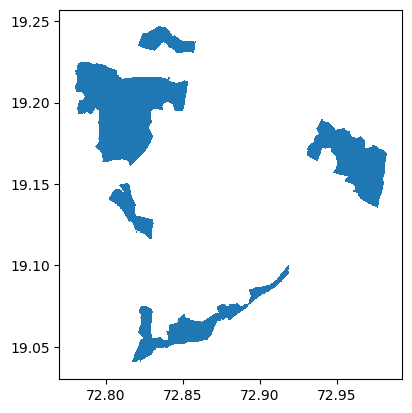

In [32]:
combined_gdf.plot(column="State Name")

### Drop rows duplicated `PSU ID` (could happen)

In [33]:
duplicated_psu_id_gdf = combined_gdf[combined_gdf.duplicated(subset=["PSU ID"], keep=False)]
duplicated_psu_id_gdf

,State Code,State Name,District Code,District Name,Subdistrict Code,Subdistrict Name,TV Code,Ward Code,Ward/Village Name,PCA_ID,...,State Name_MapSolve,District Code_MapSolve,District Name_MapSolve,Subdistrict Code_MapSolve,Subdistrict Name_MapSolve,TV Code_MapSolve,TV Name,Ward Code_MapSolve,Total Population,geometry


In [34]:
duplicated_psu_id_gdf.groupby("PSU ID").plot(alpha=0.5, column="PSU ID", legend=True)

,State Code,State Name,District Code,District Name,Subdistrict Code,Subdistrict Name,TV Code,Ward Code,Ward/Village Name,PCA_ID,...,State Name_MapSolve,District Code_MapSolve,District Name_MapSolve,Subdistrict Code_MapSolve,Subdistrict Name_MapSolve,TV Code_MapSolve,TV Name,Ward Code_MapSolve,Total Population,geometry
PSU ID,,,,,,,,,,,,,,,,,,,,,


In [35]:
combined_gdf = combined_gdf.drop_duplicates(subset=["PSU ID"], keep="first")
len(combined_gdf) == combined_gdf["PSU ID"].nunique()

True

In [36]:
combined_gdf["UID"] = combined_gdf["UID"].astype(str)

In [37]:
len(combined_gdf) == combined_gdf["PSU ID"].nunique()

True

In [38]:
save_shapefiles(
    combined_gdf,
    OUTPUT_DATA_DIR / "Sampled PSUs",
    "all_sampled_PSUs",
    ["csv", "parquet", "kml"],
)

/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 'Greater Mumbai (M Corp.) (Part) WARD NO.-1045' of field all_sampled_PSUs.TV Code parsed incompletely to real 0.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value '802794-1045' of field all_sampled_PSUs.Ward Code parsed incompletely to real 802794.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Invalid value 'GOOD - Ward boundary given as expected' for boolean field all_sampled_PSUs.TV Boundary Given. Assuming it to be false.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Invalid value 'ward' for boolean field all_sampled_PSUs.SubDistrict Boundary Given. Assuming it to be false.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12

## 5. Download rooftops

#### Identify S2 cell IDs

In [39]:
s2_cell_ids = get_s2_cell_ids(combined_gdf)
len(s2_cell_ids)

Shapes with spillover after round 1: 0


/Users/amiremami/IDinsight Repos/rooftop_sampling/Panel/utils.py:126: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points = gdf.geometry.centroid.to_frame(name="geometry")


1

#### Check if identified cells cover all areas of interest

In [40]:
s2_cells_gdf = s2_cell_ids_to_shapes_gdf(s2_cell_ids)

In [41]:
# Does the S2 cell cover the entire area of the boundaries?
uncovered_area = combined_gdf.unary_union.difference(s2_cells_gdf.unary_union).area
print(f"{uncovered_area} square degrees area not covered by an S2 cell")

0.0 square degrees area not covered by an S2 cell


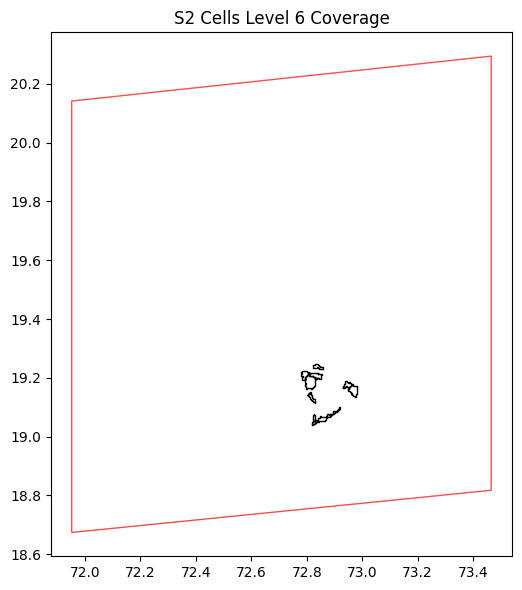

In [42]:
# Plot the S2 cells and the boundary
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
combined_gdf.boundary.plot(ax=ax, color="black", linewidth=1)
s2_cells_gdf.plot(ax=ax, facecolor="none", edgecolor="red", alpha=0.7)
plt.title("S2 Cells Level 6 Coverage")
plt.tight_layout()
plt.show()

In [43]:
s2_cells_gdf_w_state = (
    s2_cells_gdf.sjoin(
        combined_gdf[["State Name", "geometry"]], how="inner", predicate="intersects"
    )
    .drop(columns="index_right")
    .drop_duplicates()
)

In [44]:
# note: this will have duplicate s2 cell rows with different state names if the s2 cell overlaps multiple states
# this is expected and is required for the next steps logic to work correctly
s2_cells_gdf_w_state

,s2_cell_id,geometry,State Name
0,4316418767857909760,"POLYGON ((71.95199 18.67416, 73.46516 18.81752...",Maharashtra


#### Download the S2 cells

In [45]:
download_VIDA_rooftops_data_by_s2(s2_cell_ids, "IND", RAW_DATA_DIR / "02. Rooftop Data")

File 4316418767857909760 already exists.


## 6. Load rooftops and match to areas

In [46]:
state_names = combined_gdf["State Name"].sort_values().unique()
# state_names = ["Jharkhand", "Odisha", "Chhattisgarh"]

In [47]:
for state_name in tqdm(state_names):
    print(f"Processing state: {state_name}")

    # Filter the s2 cells and rooftops gdf to the current state
    s2_cell_ids = set(
        s2_cells_gdf_w_state[s2_cells_gdf_w_state["State Name"] == state_name][
            "s2_cell_id"
        ]
    )
    print(
        f"Number of S2 cells that overlap our shapes in {state_name}: {len(s2_cell_ids)}"
    )
    gdf_subset = combined_gdf[combined_gdf["State Name"] == state_name]

    # Get matched rooftops for each S2 cell in the state
    matched_rooftop_centroids_gdf_list = []
    for s2_cell_id in tqdm(s2_cell_ids):
        matched_rooftop_centroids_gdf = get_matched_rooftop_centroids_from_s2_file(
            s2_file_dir=RAW_DATA_DIR / "02. Rooftop Data",
            s2_cell_id=s2_cell_id,
            boundaries_gdf=gdf_subset,
        )
        matched_rooftop_centroids_gdf_list.append(matched_rooftop_centroids_gdf)
    matched_rooftop_centroids_gdf = pd.concat(
        matched_rooftop_centroids_gdf_list, ignore_index=True
    )
    matched_rooftop_centroids_gdf["State Name"] = state_name

    # Save the matched rooftops data
    save_shapefiles(
        matched_rooftop_centroids_gdf,
        CLEANED_DATA_DIR / "01. Matched Rooftop Data" / f"{state_name}",
        "matched_rooftops",
        ["parquet"],
    )

  0%|          | 0/1 [00:00<?, ?it/s]

Processing state: Maharashtra
Number of S2 cells that overlap our shapes in Maharashtra: 1


  0%|          | 0/1 [00:00<?, ?it/s]

/Users/amiremami/IDinsight Repos/rooftop_sampling/Panel/utils.py:223: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  s2_rooftops_gdf.geometry.centroid


In [48]:
# ax = matched_rooftop_centroids_gdf.sample(1000).plot(
#     cmap=ListedColormap(generate_colormap(len(matched_rooftop_centroids_gdf))),
# )
# gdf_subset.plot(ax=ax, color="none", edgecolor="black", linewidth=0.5)

## 7. Load matched rooftops

In [49]:
matched_rooftop_dir = CLEANED_DATA_DIR / "01. Matched Rooftop Data"
all_filepaths = list(matched_rooftop_dir.glob("**/*.parquet"))
all_filepaths = [f for f in all_filepaths if f.is_file()]

# filter to those that have selected_states in the name
all_filepaths = [
    f for f in all_filepaths if any(state in f.parent.name for state in state_names)
]

# load all shapes into one gdf
matched_rooftops_gdf_list = []
for filepath in tqdm(all_filepaths):
    matched_rooftops_gdf_list.append(gpd.read_parquet(filepath))
matched_rooftops_gdf = gpd.GeoDataFrame(
    pd.concat(matched_rooftops_gdf_list, ignore_index=True)
).to_crs(4326)

  0%|          | 0/1 [00:00<?, ?it/s]

In [50]:
len(matched_rooftops_gdf)

89836

In [51]:
no_rooftop_PSU_IDs = set(combined_gdf[combined_gdf["State Name"].isin(state_names)]["PSU ID"].unique()).difference(
    set(matched_rooftops_gdf["PSU ID"].unique())
)
no_rooftop_PSU_gdf = combined_gdf[combined_gdf["PSU ID"].isin(no_rooftop_PSU_IDs)]
no_rooftop_PSU_gdf

,State Code,State Name,District Code,District Name,Subdistrict Code,Subdistrict Name,TV Code,Ward Code,Ward/Village Name,PCA_ID,...,State Name_MapSolve,District Code_MapSolve,District Name_MapSolve,Subdistrict Code_MapSolve,Subdistrict Name_MapSolve,TV Code_MapSolve,TV Name,Ward Code_MapSolve,Total Population,geometry


In [52]:
save_shapefiles(
    no_rooftop_PSU_gdf,
    OUTPUT_DATA_DIR / "Sampled PSUs",
    "PSUs_with_no_rooftops",
    ["csv", "kml"],
)

## 8. Sample rooftops

In [53]:
# Define the base number of rooftops per ward
ROOFTOPS_PER_WARD = 75

# Sample rooftops, multiplying by Ward Count for each PSU.
sampled_rooftops = matched_rooftops_gdf.groupby("PSU ID", group_keys=False).apply(
    lambda x: x.sample(
        n=min(ROOFTOPS_PER_WARD * int(x["Ward Count"].iloc[0]), x.shape[0]),
        random_state=42,
    )
)

In [54]:
print("Length of matched_rooftops_gdf:", len(matched_rooftops_gdf))
print("Length of sampled rooftops:", len(sampled_rooftops))

Length of matched_rooftops_gdf: 89836
Length of sampled rooftops: 975


In [55]:
# Check if Ward Count is correctly influencing sample sizes
TEMP_ward_count_df = matched_rooftops_gdf[["PSU ID", "Ward Count"]].drop_duplicates()
TEMP_ward_count_df["Expected Rooftop Count"] = TEMP_ward_count_df["Ward Count"] * ROOFTOPS_PER_WARD
TEMP_sampled_counts = (
    sampled_rooftops.groupby("PSU ID").size()
).reset_index(name="Sampled Rooftop Count")

# Merge the two dataframes
TEMP_check_df = TEMP_ward_count_df.merge(TEMP_sampled_counts, on="PSU ID")
TEMP_check_df["Rooftop Count Difference"] = (
    TEMP_check_df["Expected Rooftop Count"] - TEMP_check_df["Sampled Rooftop Count"]
)
TEMP_check_df[TEMP_check_df["Rooftop Count Difference"] != 0]

,PSU ID,Ward Count,Expected Rooftop Count,Sampled Rooftop Count,Rooftop Count Difference


<Axes: >

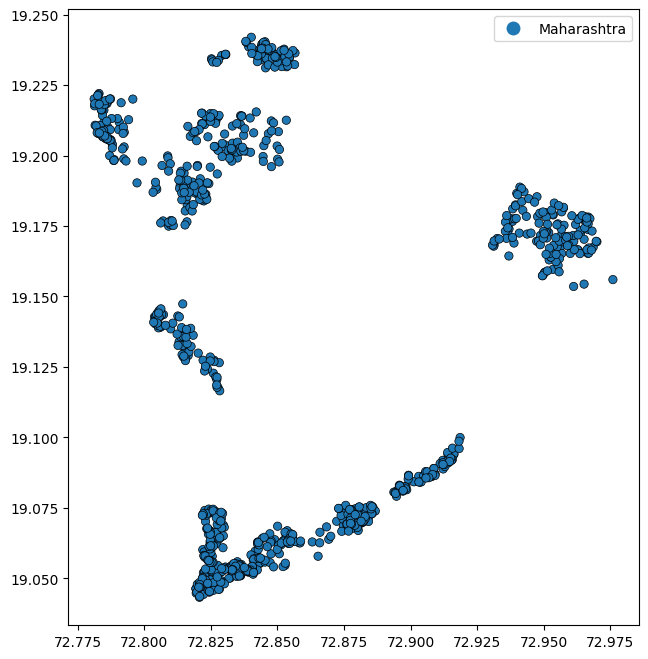

In [56]:
sampled_rooftops.plot(
    figsize=(8, 8),
    column="State Name",
    cmap="tab20",
    edgecolor="black",
    linewidth=0.5,
    legend=True,
)

## Save files

### Add sample-level rooftop numbering ID columns

In [58]:
# Rooftop number within each state
sampled_rooftops["Rooftop State ID"] = (
    sampled_rooftops.groupby("State Name").cumcount() + 1
)

# Rooftop number within each PSU ID
sampled_rooftops["Rooftop PSU ID Numeric"] = sampled_rooftops.groupby("PSU ID").cumcount() + 1
# add prefix of "PIN "  to the Rooftop PSU ID
sampled_rooftops["Rooftop PSU ID"] = "PIN " + sampled_rooftops["Rooftop PSU ID Numeric"].astype(
    str
)

# Rooftop unique ID
sampled_rooftops["Rooftop Unique ID"] = sampled_rooftops.apply(
    lambda row: f"STATE_{row['Rooftop State ID']}_PSU_ID_{row['PSU ID']}_ROOFTOP_{row['Rooftop PSU ID']}",
    axis=1,
)

### Add gmap link

In [59]:
sampled_rooftops["latitude_original"] = sampled_rooftops.geometry.y
sampled_rooftops["longitude_original"] = sampled_rooftops.geometry.x
sampled_rooftops["gmap_link_original"] = create_gmap_links(
    df=sampled_rooftops,
    lat_name="latitude_original",
    lon_name="longitude_original",
)

### Select only useful columns

**Required columns:**
- PSU info
    - Unique ID across all rooftops
    - Rooftop state ID, #
    - Rooftop PSU ID, #

    - PSU Unit: Ward, TV, Subdistrict
    - PSU sample size

- geospatial info
    - google maps link
    - coordinates
    - geometry

- Admin location info
    - State code and name
    - District code and Name
    - Subdistrict code and name
    - TV code and name
    - Ward code and name

In [60]:
chosen_cols = [
    ## IDs
    "Rooftop State ID",
    "Rooftop PSU ID",
    "Rooftop PSU ID Numeric",
    "Rooftop Unique ID",
    ## Geospatial data
    "geometry",
    "latitude_original",
    "longitude_original",
    "gmap_link_original",
    ## PSU info
    "PSU ID",
    "PSU Type",
    "Ward Count",
    ## Location info
    "State Code",
    "State Name",
    "State Changed",
    "District Code",
    "District Name",
    "Subdistrict Code",
    "Subdistrict Name",
    "TV Code",
    "TV Name",  # (from MapSolve)
    "Ward Code",
    "Ward/Village Name",
    "Urban/Rural",
    "PCA_ID",  # combined TVCode-WardCode
    "Ward Population",
    "Subdistrict Population",
    "State Population",
    # "Complete ID",
    ## Admin information
    # "Included in Panel",
    "Ward Boundary Available with MapSolve",
    # "State Shared by MapSolve",
    "Ward Boundary Given",
    "TV Boundary Given",
    "SubDistrict Boundary Given",
    "Delivery State",
    # "UID",
    # "s2_rooftop_id",
    ## MapSolve location info
    "State Code_MapSolve",
    "State Name_MapSolve",
    "District Code_MapSolve",
    "District Name_MapSolve",
    "Subdistrict Code_MapSolve",
    "Subdistrict Name_MapSolve",
    "TV Code_MapSolve",
    # "TV Name",
    "Ward Code_MapSolve",
    # "PCA_ID_MapSolve",
    "Total Population",
    # ## rooftop info
    # "boundary_id",
    # "bf_source",
    # "confidence",
    # "area_in_meters",
    # "s2_id",
    # "country_iso",
    # "geohash",
    # "bbox",
]

In [61]:
sampled_rooftops_organised_gdf = sampled_rooftops[chosen_cols]

In [62]:
sampled_rooftops_organised_gdf.rename(
    columns={
        "TV Name": "TV Name_MapSolve",
        "PSU ID": "PSU ID",
        "Total Population": "PSU Total Population_MapSolve",
    },
    inplace=True,
)

/var/folders/99/cwxq7sdx5d94rqxj57_crqbc0000gn/T/ipykernel_4239/357453037.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sampled_rooftops_organised_gdf.rename(


In [63]:
# set Ward Codes of 0.0 to NaN
sampled_rooftops_organised_gdf.loc[
    sampled_rooftops_organised_gdf["Ward Code"] == 0.0, "Ward Code"
] = np.nan

In [64]:
sampled_rooftops_organised_gdf

,Rooftop State ID,Rooftop PSU ID,Rooftop PSU ID Numeric,Rooftop Unique ID,geometry,latitude_original,longitude_original,gmap_link_original,PSU ID,PSU Type,...,Delivery State,State Code_MapSolve,State Name_MapSolve,District Code_MapSolve,District Name_MapSolve,Subdistrict Code_MapSolve,Subdistrict Name_MapSolve,TV Code_MapSolve,Ward Code_MapSolve,PSU Total Population_MapSolve
9545,1,PIN 1,1,STATE_1_PSU_ID_WARD_802794-1045_ROOFTOP_PIN 1,POINT (72.85284 19.05455),19.054548,72.852841,https://www.google.com/maps/search/?api=1&quer...,WARD_802794-1045,ward,...,GOOD - Ward boundary given as expected,27.0,Maharashtra,NaN,None,99999.0,None,802794.0,1045.0,185572.0
13596,2,PIN 2,2,STATE_2_PSU_ID_WARD_802794-1045_ROOFTOP_PIN 2,POINT (72.85810 19.06258),19.062579,72.858097,https://www.google.com/maps/search/?api=1&quer...,WARD_802794-1045,ward,...,GOOD - Ward boundary given as expected,27.0,Maharashtra,NaN,None,99999.0,None,802794.0,1045.0,185572.0
13205,3,PIN 3,3,STATE_3_PSU_ID_WARD_802794-1045_ROOFTOP_PIN 3,POINT (72.85507 19.06568),19.065675,72.855066,https://www.google.com/maps/search/?api=1&quer...,WARD_802794-1045,ward,...,GOOD - Ward boundary given as expected,27.0,Maharashtra,NaN,None,99999.0,None,802794.0,1045.0,185572.0
8834,4,PIN 4,4,STATE_4_PSU_ID_WARD_802794-1045_ROOFTOP_PIN 4,POINT (72.84421 19.05667),19.056669,72.844206,https://www.google.com/maps/search/?api=1&quer...,WARD_802794-1045,ward,...,GOOD - Ward boundary given as expected,27.0,Maharashtra,NaN,None,99999.0,None,802794.0,1045.0,185572.0
8089,5,PIN 5,5,STATE_5_PSU_ID_WARD_802794-1045_ROOFTOP_PIN 5,POINT (72.84089 19.05644),19.056436,72.840892,https://www.google.com/maps/search/?api=1&quer...,WARD_802794-1045,ward,...,GOOD - Ward boundary given as expected,27.0,Maharashtra,NaN,None,99999.0,None,802794.0,1045.0,185572.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88743,971,PIN 71,71,STATE_971_PSU_ID_WARD_802794-2487_ROOFTOP_PIN 71,POINT (72.94974 19.17996),19.179964,72.949743,https://www.google.com/maps/search/?api=1&quer...,WARD_802794-2487,ward,...,GOOD - Ward boundary given as expected,27.0,Maharashtra,NaN,None,99999.0,None,802794.0,2487.0,206590.0
85110,972,PIN 72,72,STATE_972_PSU_ID_WARD_802794-2487_ROOFTOP_PIN 72,POINT (72.94019 19.18610),19.186097,72.940185,https://www.google.com/maps/search/?api=1&quer...,WARD_802794-2487,ward,...,GOOD - Ward boundary given as expected,27.0,Maharashtra,NaN,None,99999.0,None,802794.0,2487.0,206590.0
79719,973,PIN 73,73,STATE_973_PSU_ID_WARD_802794-2487_ROOFTOP_PIN 73,POINT (72.93329 19.17036),19.170357,72.933290,https://www.google.com/maps/search/?api=1&quer...,WARD_802794-2487,ward,...,GOOD - Ward boundary given as expected,27.0,Maharashtra,NaN,None,99999.0,None,802794.0,2487.0,206590.0
89796,974,PIN 74,74,STATE_974_PSU_ID_WARD_802794-2487_ROOFTOP_PIN 74,POINT (72.95562 19.18222),19.182218,72.955622,https://www.google.com/maps/search/?api=1&quer...,WARD_802794-2487,ward,...,GOOD - Ward boundary given as expected,27.0,Maharashtra,NaN,None,99999.0,None,802794.0,2487.0,206590.0


### Save sampled data (original rooftop pins)

In [65]:
sampled_rooftops_organised_gdf["Subdistrict Population"] = sampled_rooftops_organised_gdf["Subdistrict Population"].astype(str)
sampled_rooftops_organised_gdf["State Population"] = sampled_rooftops_organised_gdf["State Population"].astype(str)

/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/geopandas/geodataframe.py:1543: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/geopandas/geodataframe.py:1543: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [66]:
save_shapefiles(
    sampled_rooftops_organised_gdf,
    OUTPUT_DATA_DIR / "01. Sampled Rooftop Data",
    "sampled_rooftops_centroids_original",
    ["csv", "parquet"],
)

save_shapefiles(
    sampled_rooftops_organised_gdf.drop(columns=["gmap_link_original"]),
    OUTPUT_DATA_DIR / "01. Sampled Rooftop Data",
    "sampled_rooftops_centroids_original",
    ["kml"],
)

/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Field sampled_rooftops_centroids_original.Rooftop PSU ID Numeric: Lossy conversion occurred when trying to set 64 bit integer field from real value 19.05454758981212.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 'WARD_802794-1045' of field sampled_rooftops_centroids_original.latitude_original parsed incompletely to real 0.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 'ward' of field sampled_rooftops_centroids_original.longitude_original parsed incompletely to real 0.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 'No' of field sampled_rooftops_centroids_original.State Code parsed incompletely to real 0.
  ogr_write(
/Users/amiremami/.py

## 9. Snap points to road

In [67]:
import yaml
from shapely import Point

from utils import get_nearest_points_on_road_batch, get_nearest_points_on_road_batch_parallel

In [68]:
# load API key
with open("../secrets/api_keys.yaml", "r") as f:
    config = yaml.safe_load(f)
    api_key = config["GOOGLE_ROADS_API_KEY"]

In [69]:
get_nearest_points_on_road_batch([Point(77.11432151622034, 28.677391409999522)], api_key)

[<POINT (77.114 28.677)>]

In [70]:
# test
get_nearest_points_on_road_batch(sampled_rooftops_organised_gdf.geometry.iloc[:5], api_key)

[<POINT (72.853 19.054)>,
 <POINT (72.858 19.063)>,
 <POINT (72.855 19.066)>,
 <POINT (72.844 19.057)>,
 <POINT (72.841 19.056)>]

In [71]:
get_nearest_points_on_road_batch_parallel(sampled_rooftops_organised_gdf.iloc[:150], api_key)

Snapping points to roads (batched):   0%|          | 0/2 [00:00<?, ?it/s]

9545     POINT (72.85282 19.05430)
13596    POINT (72.85814 19.06251)
13205    POINT (72.85509 19.06563)
8834     POINT (72.84440 19.05668)
8089     POINT (72.84088 19.05637)
                   ...            
3918     POINT (72.83752 19.05395)
4214     POINT (72.84124 19.05197)
3561     POINT (72.83452 19.05425)
2375     POINT (72.83330 19.05330)
2352     POINT (72.83255 19.05273)
Length: 150, dtype: geometry

#### Snap points to road

In [72]:
snapped_points_series = get_nearest_points_on_road_batch_parallel(
    sampled_rooftops_organised_gdf, api_key, max_workers=12
)
# took 1 second for 1,600 points (Panel)
# 30s for all 53,000 points 

Snapping points to roads (batched):   0%|          | 0/10 [00:00<?, ?it/s]

In [73]:
sampled_rooftops_snapped_gdf = sampled_rooftops_organised_gdf.copy()
sampled_rooftops_snapped_gdf["geometry_snapped"] = sampled_rooftops_snapped_gdf.index.map(snapped_points_series)

In [74]:
# Make new Geometry Type column which has values "Original" or "Snapped to Road"
sampled_rooftops_snapped_gdf["Geometry Type"] = (
    sampled_rooftops_snapped_gdf["geometry_snapped"]
    .notna()
    .replace({True: "Snapped to Road", False: "Original"})
)
sampled_rooftops_snapped_gdf["Geometry Type"].value_counts()

Geometry Type
Snapped to Road    948
Original            27
Name: count, dtype: int64

#### Replace geometry to snapped one (missing filled in with original)

In [75]:
# backup the original geometry
sampled_rooftops_snapped_gdf["geometry_original"] = sampled_rooftops_snapped_gdf[
    "geometry"
]
# replace the original geometry with the snapped geometry
sampled_rooftops_snapped_gdf["geometry"] = sampled_rooftops_snapped_gdf[
    "geometry_snapped"
]
# drop the snapped geometry column
sampled_rooftops_snapped_gdf = sampled_rooftops_snapped_gdf.drop(
    columns=["geometry_snapped"]
)
# fill in NaN values in the snapped geometry with the original geometry
sampled_rooftops_snapped_gdf["geometry"] = sampled_rooftops_snapped_gdf[
    "geometry"
].fillna(sampled_rooftops_snapped_gdf["geometry_original"])

In [76]:
sampled_rooftops_snapped_gdf["geometry"].isna().sum()

0

#### Update lat, lon, gmap_link

In [77]:
sampled_rooftops_snapped_gdf["latitude"] = list(sampled_rooftops_snapped_gdf.geometry.y)
sampled_rooftops_snapped_gdf["longitude"] = list(
    sampled_rooftops_snapped_gdf.geometry.x
)
sampled_rooftops_snapped_gdf["gmap_link"] = create_gmap_links(
    df=sampled_rooftops_snapped_gdf,
    lat_name="latitude",
    lon_name="longitude",
)

#### Reorganise

In [78]:
sampled_rooftops_snapped_gdf = sampled_rooftops_snapped_gdf[
    [
        "Rooftop State ID",
        "Rooftop PSU ID",
        "Rooftop PSU ID Numeric",
        "Rooftop Unique ID",
        # new columns start
        "Geometry Type",
        "geometry",
        "latitude",
        "longitude",
        "gmap_link",
        # new columns end
        "geometry_original",
        "latitude_original",
        "longitude_original",
        "gmap_link_original",
        "PSU ID",
        "PSU Type",
        "Ward Count",
        "State Code",
        "State Name",
        "State Changed",
        "District Code",
        "District Name",
        "Subdistrict Code",
        "Subdistrict Name",
        "TV Code",
        "TV Name_MapSolve",
        "Ward Code",
        "Ward/Village Name",
        "Urban/Rural",
        "PCA_ID",
        "Ward Population",
        "Subdistrict Population",
        "State Population",
        # "Included in Panel",
        "Ward Boundary Available with MapSolve",
        "Ward Boundary Given",
        "TV Boundary Given",
        "SubDistrict Boundary Given",
        "Delivery State",
        "State Code_MapSolve",
        "State Name_MapSolve",
        "District Code_MapSolve",
        "District Name_MapSolve",
        "Subdistrict Code_MapSolve",
        "Subdistrict Name_MapSolve",
        "TV Code_MapSolve",
        "Ward Code_MapSolve",
        # "PCA_ID_MapSolve",
        "PSU Total Population_MapSolve",
    ]
]

#### Make lines between original and snapped points

In [79]:
from shapely.geometry import LineString

In [80]:
sampled_rooftops_snapped_gdf["geometry_line"] = sampled_rooftops_snapped_gdf.apply(
    lambda row: LineString([row["geometry_original"], row["geometry"]]), axis=1
)

In [81]:
sampled_rooftops_snapped_gdf["geometry_line"].isna().sum()

0

#### Save new files: snapped points, snapped lines

In [82]:
# Save CSV and parquet
save_shapefiles(
    sampled_rooftops_snapped_gdf.drop(
        columns=[
            "geometry_original",
            "geometry_line",
        ]
    ),
    OUTPUT_DATA_DIR / "01. Sampled Rooftop Data",
    "sampled_rooftops_snapped_points",
    ["csv", "parquet"],
)

In [83]:
# Save KML
save_shapefiles(
    sampled_rooftops_snapped_gdf.drop(
        columns=[
            "geometry_original",
            "geometry_line",
            # bad cols for KML
            "gmap_link_original",
            "gmap_link"
        ]
    ),
    OUTPUT_DATA_DIR / "01. Sampled Rooftop Data",
    "sampled_rooftops_snapped_points",
    ["kml"],
)

/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 'WARD_802794-1045' of field sampled_rooftops_snapped_points.latitude_original parsed incompletely to real 0.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 'ward' of field sampled_rooftops_snapped_points.longitude_original parsed incompletely to real 0.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 'No' of field sampled_rooftops_snapped_points.State Code parsed incompletely to real 0.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 'Urban' of field sampled_rooftops_snapped_points.Ward Code parsed incompletely to real 0.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWar

In [84]:
# Save lines
sampled_rooftops_line_gdf = sampled_rooftops_snapped_gdf.copy()
sampled_rooftops_line_gdf["geometry"] = sampled_rooftops_line_gdf["geometry_line"]
sampled_rooftops_line_gdf = sampled_rooftops_line_gdf.drop(
    columns=["geometry_original", "geometry_line"]
)

In [85]:
save_shapefiles(
    sampled_rooftops_line_gdf.drop(
        # drop kml unfriendly columns
        columns=["gmap_link_original", "gmap_link"]
    ),
    OUTPUT_DATA_DIR / "01. Sampled Rooftop Data",
    "sampled_rooftops_snapped_lines",
    ["parquet", "kml"],
)

/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 'WARD_802794-1045' of field sampled_rooftops_snapped_lines.latitude_original parsed incompletely to real 0.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 'ward' of field sampled_rooftops_snapped_lines.longitude_original parsed incompletely to real 0.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 'No' of field sampled_rooftops_snapped_lines.State Code parsed incompletely to real 0.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 'Urban' of field sampled_rooftops_snapped_lines.Ward Code parsed incompletely to real 0.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning

## Save per state

In [86]:
for state in tqdm(sampled_rooftops_organised_gdf["State Name"].unique()):
    state_output_folder = OUTPUT_DATA_DIR / "01. Sampled Rooftop Data" / "State-Level" / state

    # save original points
    selected_state_original_gdf = sampled_rooftops_organised_gdf[
        sampled_rooftops_organised_gdf["State Name"] == state
    ]

    save_shapefiles(
        selected_state_original_gdf,
        state_output_folder,
        f"{state}_sampled_rooftops_centroids_original",
        ["csv", "parquet"],
    )
    save_shapefiles(
        selected_state_original_gdf.drop(
            # drop kml unfriendly columns
            columns=["gmap_link_original"]
        ),
        state_output_folder,
        f"{state}_sampled_rooftops_centroids_original",
        ["kml"],
    )

    # Save snapped points
    selected_state_snapped_gdf = sampled_rooftops_snapped_gdf[
        sampled_rooftops_snapped_gdf["State Name"] == state
    ].drop(
        columns=[
            "geometry_original",
            "geometry_line",
        ]
    )
    save_shapefiles(
        selected_state_snapped_gdf,
        state_output_folder,
        f"{state}_sampled_rooftops_snapped_points",
        ["csv", "parquet"],
    )
    save_shapefiles(
        selected_state_snapped_gdf.drop(
            # drop kml unfriendly columns
            columns=["gmap_link_original", "gmap_link"]
        ),
        state_output_folder,
        f"{state}_sampled_rooftops_snapped_points",
        ["kml"],
    )

    # Save lines
    selected_state_sampled_rooftops_line_gdf = sampled_rooftops_line_gdf[
        sampled_rooftops_line_gdf["State Name"] == state
    ]
    save_shapefiles(
        selected_state_sampled_rooftops_line_gdf.drop(
            # drop kml unfriendly columns
            columns=["gmap_link_original", "gmap_link"]
        ),
        state_output_folder,
        f"{state}_sampled_rooftops_snapped_lines",
        ["parquet", "kml"],
    )

  0%|          | 0/1 [00:00<?, ?it/s]

/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Field Maharashtra_sampled_rooftops_centroids_original.Rooftop PSU ID Numeric: Lossy conversion occurred when trying to set 64 bit integer field from real value 19.05454758981212.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 'WARD_802794-1045' of field Maharashtra_sampled_rooftops_centroids_original.latitude_original parsed incompletely to real 0.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 'ward' of field Maharashtra_sampled_rooftops_centroids_original.longitude_original parsed incompletely to real 0.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 'No' of field Maharashtra_sampled_rooftops_centroids_original.State Code parsed incomplet

### Save slices per state

In [87]:
from math import ceil
SLICE_SIZE = 25
N_SLICES = ceil(ROOFTOPS_PER_WARD / SLICE_SIZE)

print(f"ROOFTOPS_PER_WARD: {ROOFTOPS_PER_WARD}")
print(f"SLICE_SIZE: {SLICE_SIZE}")
print(f"N_SLICES: {N_SLICES}")
print(f"N_SLICES * SLICE_SIZE: {N_SLICES * SLICE_SIZE}")

ROOFTOPS_PER_WARD: 75
SLICE_SIZE: 25
N_SLICES: 3
N_SLICES * SLICE_SIZE: 75


In [88]:
sampled_rooftops_organised_gdf["State Name"].unique()

array(['Maharashtra'], dtype=object)

In [89]:
for state in tqdm(sampled_rooftops_organised_gdf["State Name"].unique()):
    state_gdf = sampled_rooftops_organised_gdf[
        sampled_rooftops_organised_gdf["State Name"] == state
    ]
    for slice_idx in range(N_SLICES):

        original_points_slice_rows = []
        snapped_points_slice_rows = []
        line_slice_rows = []

        for psu_id, psu_df in state_gdf.groupby("PSU ID"):
            # get counts and indices from the original dataframe (also applies to the other two)
            ward_count = int(psu_df["Ward Count"].iloc[0])
            start_idx = slice_idx * SLICE_SIZE * ward_count
            end_idx = start_idx + (SLICE_SIZE * ward_count)

            # original points
            psu_original_slice = sampled_rooftops_organised_gdf[
                (sampled_rooftops_organised_gdf["State Name"] == state)
                & (sampled_rooftops_organised_gdf["PSU ID"] == psu_id)
            ].iloc[start_idx:end_idx]
            original_points_slice_rows.append(psu_original_slice)

            # snapped points
            psu_snapped_slice = sampled_rooftops_snapped_gdf[
                (sampled_rooftops_snapped_gdf["State Name"] == state)
                & (sampled_rooftops_snapped_gdf["PSU ID"] == psu_id)
            ].iloc[start_idx:end_idx]
            snapped_points_slice_rows.append(psu_snapped_slice)

            # lines
            psu_line_slice = sampled_rooftops_line_gdf[
                (sampled_rooftops_line_gdf["State Name"] == state)
                & (sampled_rooftops_line_gdf["PSU ID"] == psu_id)
            ].iloc[start_idx:end_idx]
            line_slice_rows.append(psu_line_slice)


        # Concatenate all PSU slices for this state and slice
        state_slice_original_gdf = pd.concat(original_points_slice_rows, ignore_index=True)
        state_slice_snapped_gdf = pd.concat(snapped_points_slice_rows, ignore_index=True)
        state_slice_line_gdf = pd.concat(line_slice_rows, ignore_index=True)

        # set folder
        state_slice_output_folder = (
            OUTPUT_DATA_DIR
            / "01. Sampled Rooftop Data"
            / "State-Level"
            / state
            / f"slice_{slice_idx}"
        )

        # Save original points
        save_shapefiles(
            state_slice_original_gdf,
            state_slice_output_folder,
            f"{state}_sampled_rooftops_centroids_original_{slice_idx}",
            ["csv", "parquet"],
        )
        save_shapefiles(
            state_slice_original_gdf.drop(columns=["gmap_link_original"]),
            state_slice_output_folder,
            f"{state}_sampled_rooftops_centroids_original_{slice_idx}",
            ["kml"],
        )

        # Save snapped points
        save_shapefiles(
            state_slice_snapped_gdf,
            state_slice_output_folder,
            f"{state}_sampled_rooftops_snapped_points_{slice_idx}",
            ["csv", "parquet"],
        )
        save_shapefiles(
            state_slice_snapped_gdf.drop(
                # drop kml unfriendly columns
                columns=["gmap_link_original", "gmap_link", "geometry_line", "geometry_original"]
            ),
            state_slice_output_folder,
            f"{state}_sampled_rooftops_snapped_points_{slice_idx}",
            ["kml"],
        )

        # Save lines
        save_shapefiles(
            state_slice_line_gdf.drop(
                # drop kml unfriendly columns
                columns=["gmap_link_original", "gmap_link"]
            ),
            state_slice_output_folder,
            f"{state}_sampled_rooftops_snapped_lines_{slice_idx}",
            ["parquet", "kml"],
        )

  0%|          | 0/1 [00:00<?, ?it/s]

/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Field Maharashtra_sampled_rooftops_centroids_original_0.Rooftop PSU ID Numeric: Lossy conversion occurred when trying to set 64 bit integer field from real value 19.05454758981212.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 'WARD_802794-1045' of field Maharashtra_sampled_rooftops_centroids_original_0.latitude_original parsed incompletely to real 0.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 'ward' of field Maharashtra_sampled_rooftops_centroids_original_0.longitude_original parsed incompletely to real 0.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 'No' of field Maharashtra_sampled_rooftops_centroids_original_0.State Code parsed i

## Save per-PSU

In [90]:
for psu_id in tqdm(sampled_rooftops_organised_gdf["PSU ID"].unique()):

    # save original points
    selected_psu_original_gdf = sampled_rooftops_organised_gdf[
        sampled_rooftops_organised_gdf["PSU ID"] == psu_id
    ]

    # for folder name
    first_row = selected_psu_original_gdf.iloc[0]
    psu_type = first_row["PSU Type"]
    state_name = first_row["State Name"].strip().replace(" ", "_")
    district_name = first_row["District Name"].strip().replace(" ", "_")
    subdistrict_name = first_row["Subdistrict Name"].strip().replace(" ", "_")
    tv_code = int(first_row["TV Code"]) if pd.notna(first_row["TV Code"]) else None
    ward_code = int(first_row["Ward Code"]) if pd.notna(first_row["Ward Code"]) else None

    if psu_type == "ward":
        foldername = f"{state_name}_DIST_{district_name}_SUBDIST_{subdistrict_name}_TV_{tv_code}_WARD_{ward_code}_PSUID_{psu_id}"
    elif psu_type == "town_village":
        foldername = f"{state_name}_DIST_{district_name}_SUBDIST_{subdistrict_name}_TV_{tv_code}_PSUID_{psu_id}"
    elif psu_type == "subdistrict":
        foldername = f"{state_name}_DIST_{district_name}_SUBDIST_{subdistrict_name}_PSUID_{psu_id}"
    else:
        raise ValueError(f"Unknown PSU Type: {psu_type}")
    psu_output_folder = OUTPUT_DATA_DIR / "01. Sampled Rooftop Data" / "PSU-Level" / foldername
    psu_output_folder.mkdir(parents=True, exist_ok=True)

    save_shapefiles(
        selected_psu_original_gdf,
        psu_output_folder,
        f"{psu_id}_sampled_rooftops_centroids_original",
        ["csv", "parquet"],
    )
    save_shapefiles(
        selected_psu_original_gdf.drop(
            # drop kml unfriendly columns
            columns=["gmap_link_original"]
        ),
        psu_output_folder,
        f"{psu_id}_sampled_rooftops_centroids_original",
        ["kml"],
    )

    # Save snapped points
    selected_psu_snapped_gdf = sampled_rooftops_snapped_gdf[
        sampled_rooftops_snapped_gdf["PSU ID"] == psu_id
    ].drop(
        columns=[
            "geometry_original",
            "geometry_line",
        ]
    )
    save_shapefiles(
        selected_psu_snapped_gdf,
        psu_output_folder,
        f"{psu_id}_sampled_rooftops_snapped_points",
        ["csv", "parquet"],
    )
    save_shapefiles(
        selected_psu_snapped_gdf.drop(
            # drop kml unfriendly columns
            columns=["gmap_link_original", "gmap_link"]
        ),
        psu_output_folder,
        f"{psu_id}_sampled_rooftops_snapped_points",
        ["kml"],
    )

    # Save lines
    selected_psu_sampled_rooftops_line_gdf = sampled_rooftops_line_gdf[
        sampled_rooftops_line_gdf["PSU ID"] == psu_id
    ]
    save_shapefiles(
        selected_psu_sampled_rooftops_line_gdf.drop(
            # drop kml unfriendly columns
            columns=["gmap_link_original", "gmap_link"]
        ),
        psu_output_folder,
        f"{psu_id}_sampled_rooftops_snapped_lines",
        ["parquet", "kml"],
    )

  0%|          | 0/13 [00:00<?, ?it/s]

/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Layer name 'WARD_802794-1045_sampled_rooftops_centroids_original' adjusted to 'WARD_802794_1045_sampled_rooftops_centroids_original' for XML validity.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Field WARD_802794_1045_sampled_rooftops_centroids_original.Rooftop PSU ID Numeric: Lossy conversion occurred when trying to set 64 bit integer field from real value 19.05454758981212.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 'WARD_802794-1045' of field WARD_802794_1045_sampled_rooftops_centroids_original.latitude_original parsed incompletely to real 0.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 'ward' of field WARD_802794_1045_sampled_rooftop